<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/25_hyperparameter_tuning_grid_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperparameter Tuning with Grid Search

In this notebook, we use Grid Search with Cross Validation to find the best hyperparameters for a KNN classifier.

In [3]:
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [4]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42
)

In [5]:
model = KNeighborsClassifier()

In [6]:
param_grid = {
    'n_neighbors': [1,3,5,7,9]
}

In [7]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5
)

In [8]:
grid_search.fit(X, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 7, 9]})

In [9]:
print(
    "Best Parameters:",
    grid_search.best_params_
)

Best Parameters: {'n_neighbors': 3}


In [10]:
print(
    "Best Accuracy:",
    grid_search.best_score_
)

Best Accuracy: 0.9800000000000001


In [11]:
results = pd.DataFrame(
    grid_search.cv_results_
)

results[
    ['param_n_neighbors',
     'mean_test_score']
]

,param_n_neighbors,mean_test_score
0,1,0.96
1,3,0.98
2,5,0.98
3,7,0.98
4,9,0.95


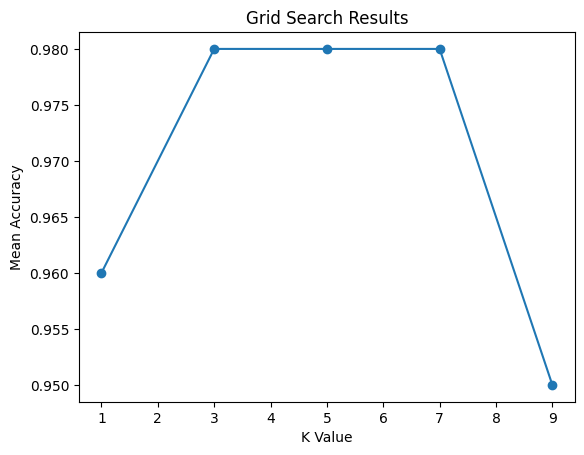

In [12]:
import matplotlib.pyplot as plt

plt.plot(
    results['param_n_neighbors'],
    results['mean_test_score'],
    marker='o'
)

plt.xlabel("K Value")

plt.ylabel("Mean Accuracy")

plt.title("Grid Search Results")

plt.show()